# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

In [7]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import matplotlib.pyplot as plt

# Set renderer
pio.renderers.default = 'plotly_mimetype'

# 1. Load Data
df = pd.read_csv('netflix_titles.csv.csv')

# 2. Clean Data for "Time" Analysis
# Convert 'date_added' to datetime objects
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='mixed')
df['year_added'] = df['date_added'].dt.year

# 3. Clean Data for "Relationship" Analysis
# We want to analyze Movie duration, but it's text ("90 min"). We need numbers.
movies = df[df['type'] == 'Movie'].copy()
movies['duration_minutes'] = movies['duration'].str.replace(' min', '').astype(float)

# 4. Clean Data for "Space" (Map) Analysis
# Some entries have multiple countries like "United States, India". 
# We split them so both countries get credit on the map.
# This separates the rows: one movie with "USA, UK" becomes two rows: "USA" and "UK"
countries_exploded = df.assign(country=df['country'].str.split(', ')).explode('country')
country_counts = countries_exploded['country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']

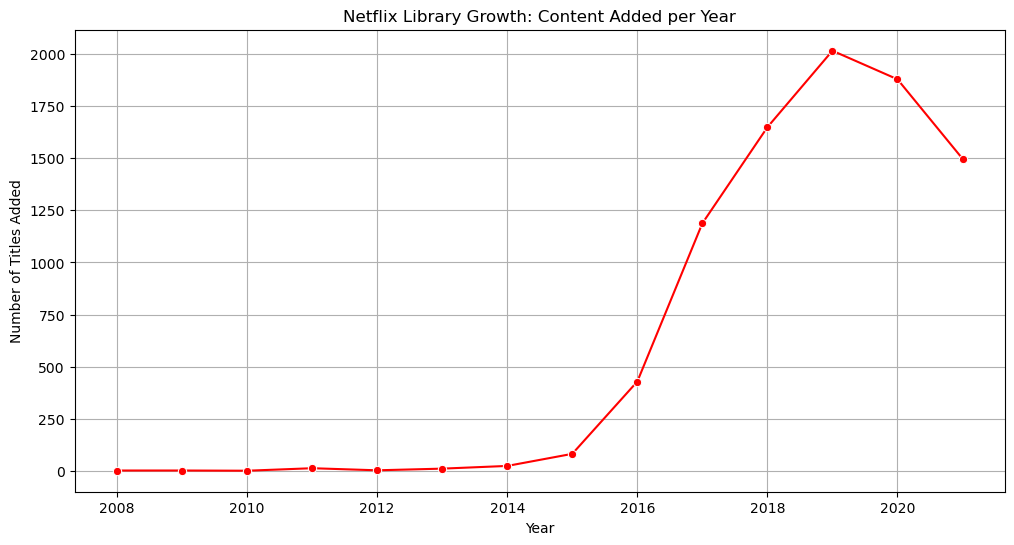

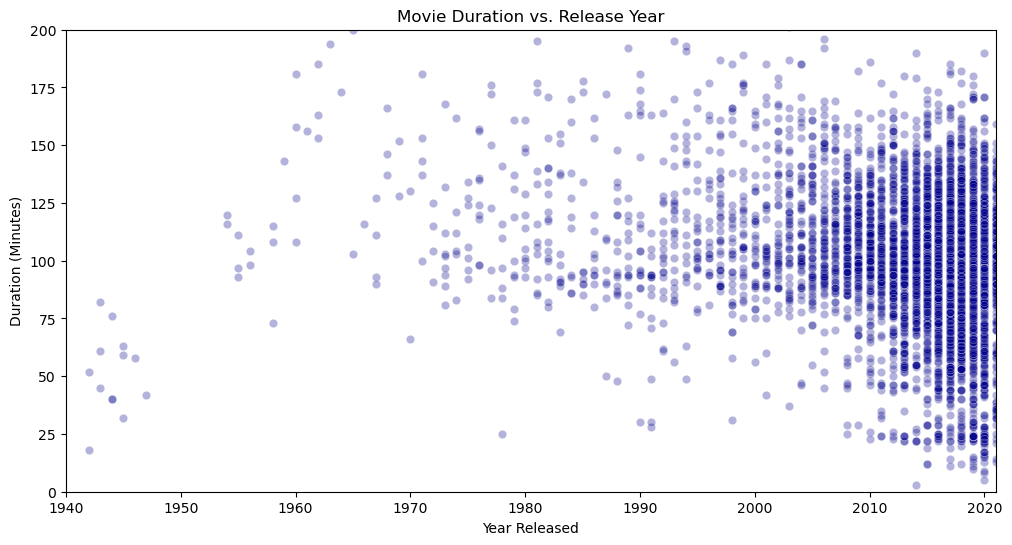

In [8]:
# --- Plot 1: Time (Content Added Over Years) ---
plt.figure(figsize=(12, 6))
# Count how many shows were added each year
content_by_year = df['year_added'].value_counts().sort_index()
# Drop 2024/future data if it looks empty or incomplete for a better graph
content_by_year = content_by_year[content_by_year.index < 2022] 

sns.lineplot(x=content_by_year.index, y=content_by_year.values, marker='o', color='red')
plt.title('Netflix Library Growth: Content Added per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True)
plt.show()

# --- Plot 2: Relationship (Movie Duration vs. Release Year) ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=movies, x='release_year', y='duration_minutes', alpha=0.3, color='darkblue')
plt.title('Movie Duration vs. Release Year')
plt.xlabel('Year Released')
plt.ylabel('Duration (Minutes)')
plt.xlim(1940, 2021) # Zoom in on the modern era
plt.ylim(0, 200)     # Ignore ultra-long documentaries for clarity
plt.show()

Netflix had a spike of movies come in from 2015 to 2019. This is about the time that On-Demand Streaming Services started to become mainstream.


there seems to be no corrolation between the duration of the movie and the year it was released. we can however See that production started to ramp up from the early 2000s to the more recent years. A mean of a Netflix film/show would be around 80 mins long.

In [9]:
# --- Plot 3: The Map (Production by Country) ---
fig = px.scatter_geo(country_counts,
                     locations='country',           # Use the country name column
                     locationmode='country names',  # Tell Plotly these are names, not coords
                     size='count',                  # Bubble size = number of movies
                     color='count',                 # Color = number of movies
                     hover_name='country',
                     projection='natural earth',    # A nice curved map projection
                     title='Netflix Content Production by Country',
                     color_continuous_scale='Reds') # Netflix red theme

fig.show()

This map shows the amount of movies that are from each country that are on netflix. The United States has the most amount of produced Netflix content.